# Local Image Drift MMD Demo

This notebook is the local example for the Image MMD KServe demo. It reads the manifest-selected external images, shows the illumination changes, converts every image into the shared 54-dimensional representation, uploads the generated data to a containerized TrustyAI service, and displays the service's multidimensional MMD results.

The notebook does not require OpenShift or KServe, but it does require the TrustyAI service container started by scripts/run_local_trustyai.sh. It never imports a local TrustyAI checkout. The representation demonstrates transport and statistical drift detection; it is not a production-grade vision model.

## Run environment

Start the containerized TrustyAI service, then start Jupyter from the demos repository root:

    bash 3b-ImageDrift/scripts/run_local_trustyai.sh
    export TRUSTYAI_URL=http://127.0.0.1:18081
    uv run --project 3b-ImageDrift --extra local jupyter lab

The demo's pyproject.toml and uv.lock provide the predictor, notebook, and plotting dependencies. TrustyAI MMD runs in the service container based on quay.io/opendatahub/odh-trustyai-service-py:odh-stable; no TRUSTYAI_SERVICE_ROOT variable or local TrustyAI source checkout is required.

In [1]:
import importlib.util
import json
import os
import shlex
import sys
from pathlib import Path

missing_modules = [
    name
    for name in ("matplotlib", "numpy", "pandas", "PIL")
    if importlib.util.find_spec(name) is None
]
if missing_modules:
    missing = ", ".join(missing_modules)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Start Jupyter with "
        "uv run --project 3b-ImageDrift --extra local jupyter lab"
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps


def locate_demo_root() -> Path:
    override = os.environ.get("DEMOS_ROOT")
    starts = [Path(override).expanduser()] if override else []
    starts.append(Path.cwd())
    for start in starts:
        resolved = start.resolve()
        for candidate in (resolved, *resolved.parents):
            if (candidate / "3b-ImageDrift" / "data" / "dataset_manifest.json").is_file():
                return candidate
    raise RuntimeError(
        "Set DEMOS_ROOT to the odh-trustyai-demos checkout containing 3b-ImageDrift."
    )

DEMO_ROOT = locate_demo_root()
DEMO_DIR = DEMO_ROOT / "3b-ImageDrift"
sys.path.insert(0, str(DEMO_DIR))

from common.image_features import embed_image_batch
from common.trustyai_client import (
    TrustyAIClient,
    TrustyAIClientError,
    compact_request_inputs,
)
from predictor.server import predict_request
from scripts.prepare_data import (
    DataPreparationError,
    build_payloads,
    load_manifest,
    verify_source,
)

TRUSTYAI_URL = os.environ.get("TRUSTYAI_URL", "http://127.0.0.1:18081")
TRUSTYAI_TOKEN = os.environ.get("TRUSTYAI_TOKEN")
TRUSTYAI_ALLOWED_HOSTS = frozenset(
    item.strip().lower()
    for item in os.environ.get("TRUSTYAI_ALLOWED_HOSTS", "").split(",")
    if item.strip()
)
TRUSTYAI_INSECURE = os.environ.get("TRUSTYAI_INSECURE", "").lower() in {"1", "true", "yes"}

try:
    trustyai_client = TrustyAIClient(
        TRUSTYAI_URL,
        token=TRUSTYAI_TOKEN,
        allowed_hosts=TRUSTYAI_ALLOWED_HOSTS,
        ca_bundle=os.environ.get("TRUSTYAI_CA_BUNDLE"),
        insecure=TRUSTYAI_INSECURE,
    )
    _service_info = trustyai_client.info()
    mmd_definition = trustyai_client.mmd_definition()
except (TrustyAIClientError, ValueError) as exc:
    raise RuntimeError(
        f"TrustyAI is unavailable at {TRUSTYAI_URL}.\n"
        "Start it with: bash 3b-ImageDrift/scripts/run_local_trustyai.sh\n"
        "Then set TRUSTYAI_URL before opening this notebook.\n"
        f"Original error: {exc}"
    ) from exc

print(f"TrustyAI endpoint: {TRUSTYAI_URL}")
print(f"MMD endpoint: {mmd_definition.get('name', 'available')}")

manifest_override = os.environ.get("IMAGE_MMD_MANIFEST")
data_root_override = os.environ.get("IMAGE_MMD_DATA_ROOT")
MANIFEST_PATH = (
    Path(manifest_override).expanduser().resolve()
    if manifest_override
    else DEMO_DIR / "data" / "dataset_manifest.json"
)
DATA_ROOT = (
    Path(data_root_override).expanduser().resolve()
    if data_root_override
    else MANIFEST_PATH.parent
)
manifest = load_manifest(MANIFEST_PATH)
DOWNLOAD_COMMAND = (
    "uv run --project 3b-ImageDrift python "
    "3b-ImageDrift/scripts/prepare_data.py download "
    f"--manifest {shlex.quote(str(MANIFEST_PATH))} "
    f"--data-root {shlex.quote(str(DATA_ROOT))}"
)

try:
    archive_path, extracted_root, _ = verify_source(manifest, DATA_ROOT)
except DataPreparationError as exc:
    raise RuntimeError(
        f"Dataset verification failed: {exc}\n"
        f"Run this acquisition command from DEMO_ROOT:\n{DOWNLOAD_COMMAND}"
    ) from exc

print(f"Dataset: {manifest.dataset['name']}")
print(f"Verified archive: {archive_path}")
print(f"Using extracted images under: {extracted_root}")
print(f"Loaded {manifest.sample_size} ordered samples.")

TrustyAI endpoint: http://127.0.0.1:18081
MMD endpoint: Maximum Mean Discrepancy (MMD)
Dataset: MIT Multi-Illumination
Verified archive: /Users/sudsinha/Repositories/work/odh-trustyai-demos/3b-ImageDrift/data/raw/multi_illumination_test_mip2_jpg.zip
Using extracted images under: /Users/sudsinha/Repositories/work/odh-trustyai-demos/3b-ImageDrift/data/raw/extracted
Loaded 30 ordered samples.


## 1. Inspect the manifest-driven experiment

The manifest is the source of truth for the ordered sample rows, reference images, current images, and human-readable conditions. Changing to another compatible dataset profile changes this table, not the notebook logic.

In [2]:
manifest_rows = []
for sample in manifest.samples:
    row = {
        "sample_id": sample.sample_id,
        "reference": sample.reference.condition,
    }
    for case in manifest.cases:
        row[case] = sample.current[case].condition
    manifest_rows.append(row)

manifest_table = pd.DataFrame(manifest_rows)
display(manifest_table)

,sample_id,reference,identical,near,mild,strong
0,everett_dining1,direction 0,direction 0,direction 1,direction 14,direction 24
1,everett_dining2,direction 0,direction 0,direction 1,direction 14,direction 24
2,everett_kitchen2,direction 0,direction 0,direction 1,direction 14,direction 24
3,everett_kitchen4,direction 0,direction 0,direction 1,direction 14,direction 24
4,everett_kitchen5,direction 0,direction 0,direction 1,direction 14,direction 24
5,everett_kitchen6,direction 0,direction 0,direction 1,direction 14,direction 24
6,everett_kitchen7,direction 0,direction 0,direction 1,direction 14,direction 24
7,everett_kitchen8,direction 0,direction 0,direction 1,direction 14,direction 24
8,everett_kitchen9,direction 0,direction 0,direction 1,direction 14,direction 24
9,everett_kitchen12,direction 0,direction 0,direction 1,direction 14,direction 24


## 2. See the image changes

The first figure shows every condition for one scene. The second compares the reference and strong-shift images across several scenes. Change `sample_index` or `preview_indices` to explore other manifest rows.

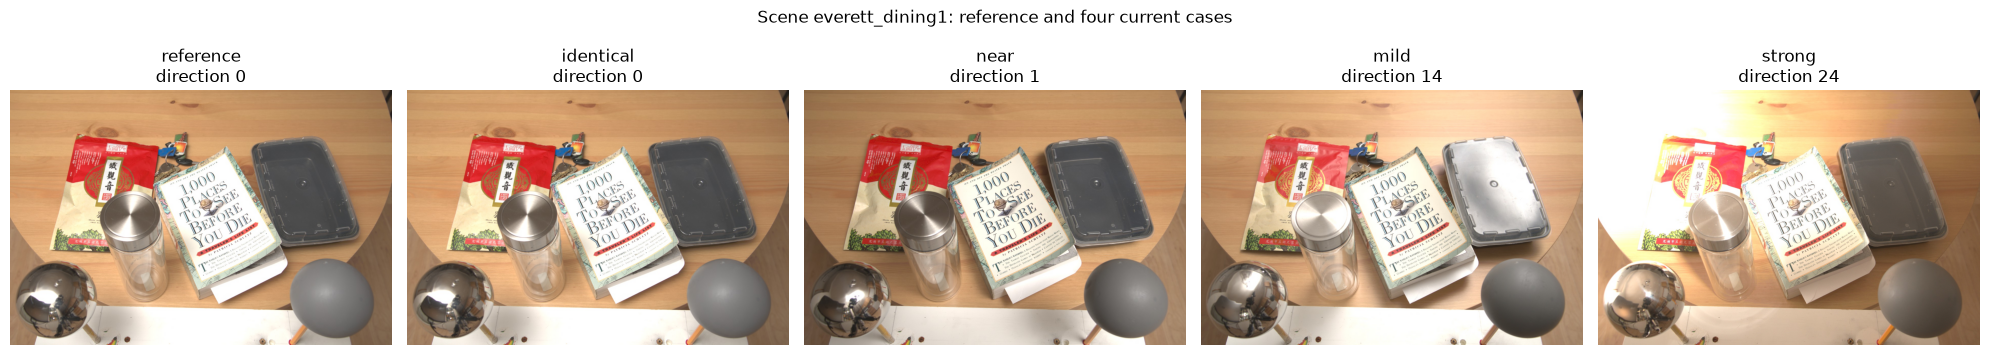

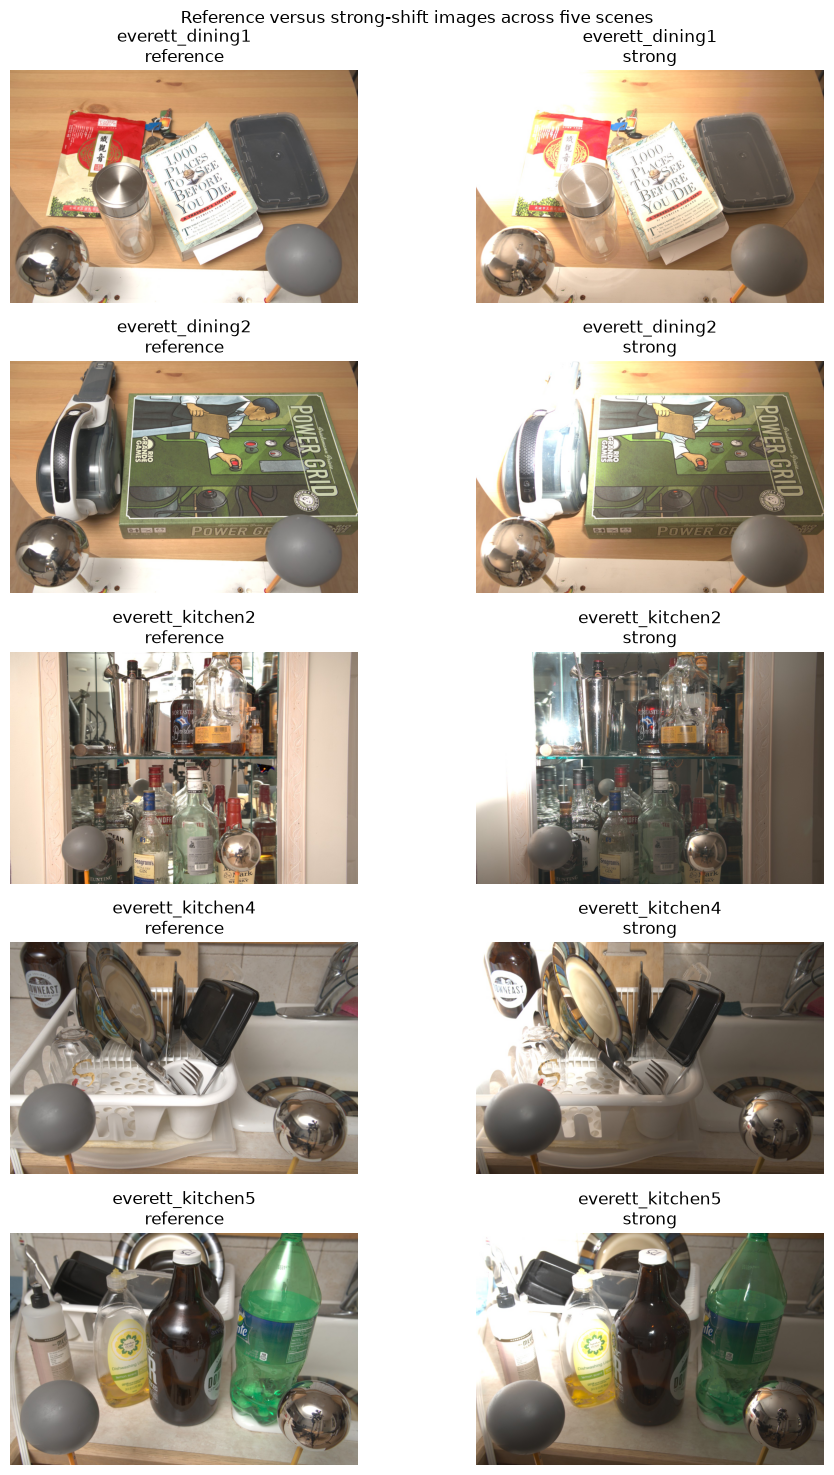

In [3]:
def read_rgb(path: Path) -> Image.Image:
    with Image.open(path) as image:
        return ImageOps.exif_transpose(image).convert("RGB").copy()


sample_index = 0
sample = manifest.samples[sample_index]
selected_images = [("reference", sample.reference)] + [
    (case, sample.current[case]) for case in manifest.cases
]

figure, axes = plt.subplots(1, len(selected_images), figsize=(20, 4))
for axis, (label, selection) in zip(axes, selected_images):
    image = read_rgb(extracted_root / selection.member)
    axis.imshow(image)
    axis.set_title(f"{label}\n{selection.condition}")
    axis.axis("off")
figure.suptitle(f"Scene {sample.sample_id}: reference and four current cases")
figure.tight_layout()
plt.show()

preview_indices = list(range(min(5, manifest.sample_size)))
figure, axes = plt.subplots(len(preview_indices), 2, figsize=(10, 3 * len(preview_indices)))
axes = np.atleast_2d(axes)
for row, index in enumerate(preview_indices):
    preview_sample = manifest.samples[index]
    reference_image = read_rgb(extracted_root / preview_sample.reference.member)
    strong_image = read_rgb(
        extracted_root / preview_sample.current["strong"].member
    )
    axes[row, 0].imshow(reference_image)
    axes[row, 0].set_title(f"{preview_sample.sample_id}\nreference")
    axes[row, 1].imshow(strong_image)
    axes[row, 1].set_title(f"{preview_sample.sample_id}\nstrong")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
figure.suptitle("Reference versus strong-shift images across five scenes")
figure.tight_layout()
plt.show()

## 3. Encode the images and inspect feature-space movement

Each batch has shape `(30, 54)). The distance chart is a descriptive view of how far each current embedding moved from its paired reference embedding. MMD below is the statistical test over all 54 columns, not a per-image distance threshold.

,case,embedding_shape
0,reference,"(30, 54)"
1,identical,"(30, 54)"
2,near,"(30, 54)"
3,mild,"(30, 54)"
4,strong,"(30, 54)"


,case,mean_l2_distance,median_l2_distance,max_l2_distance
0,identical,0.0000,0.0000,0.0000
1,near,0.5876,0.5603,1.2582
2,mild,0.8711,0.7676,1.7052
3,strong,1.2716,1.3022,1.9591


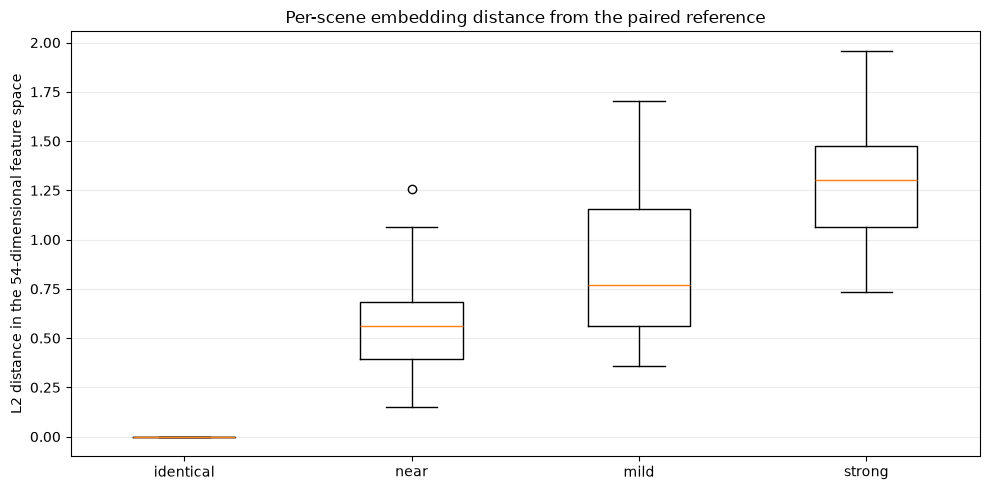

In [4]:
reference_bytes = [
    (extracted_root / sample.reference.member).read_bytes()
    for sample in manifest.samples
]
reference_embeddings = embed_image_batch(reference_bytes)

current_bytes = {
    case: [
        (extracted_root / sample.current[case].member).read_bytes()
        for sample in manifest.samples
    ]
    for case in manifest.cases
}
current_embeddings = {
    case: embed_image_batch(images)
    for case, images in current_bytes.items()
}

shape_table = pd.DataFrame(
    [
        {"case": "reference", "embedding_shape": reference_embeddings.shape}
    ]
    + [
        {"case": case, "embedding_shape": embeddings.shape}
        for case, embeddings in current_embeddings.items()
    ]
)
display(shape_table)

distance_rows = []
case_distances = {}
for case, embeddings in current_embeddings.items():
    distances = np.linalg.norm(embeddings - reference_embeddings, axis=1)
    case_distances[case] = distances
    distance_rows.append(
        {
            "case": case,
            "mean_l2_distance": distances.mean(),
            "median_l2_distance": np.median(distances),
            "max_l2_distance": distances.max(),
        }
    )

distance_table = pd.DataFrame(distance_rows)
display(distance_table.round(4))

figure, axis = plt.subplots(figsize=(10, 5))
axis.boxplot(
    [case_distances[case] for case in manifest.cases],
    tick_labels=list(manifest.cases),
)
axis.set_title("Per-scene embedding distance from the paired reference")
axis.set_ylabel("L2 distance in the 54-dimensional feature space")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()

## 4. Compute MMD and interpret the result

MMD is computed by the containerized TrustyAI service once per case using the same settings as the remote workflow: CTT, alpha 0.05, seed 7, 199 permutations, and all 54 embedding columns. The local embedding arrays above are diagnostics; the result table below comes from the HTTP service. Before upload, `compact_request_inputs` replaces the large base64 image request bodies with empty placeholders. The response embeddings and row counts are unchanged, while the upload fits the service image's default local PVC row-size limit.

,case,condition,statistic,p_value,threshold,drift_detected
0,identical,direction 0 -> direction 0,0.029191,0.910,0.047135,False
1,near,direction 0 -> direction 1,0.030597,0.910,0.046887,False
2,mild,direction 0 -> direction 14,0.038612,0.295,0.046600,False
3,strong,direction 0 -> direction 24,0.056772,0.005,0.040837,True


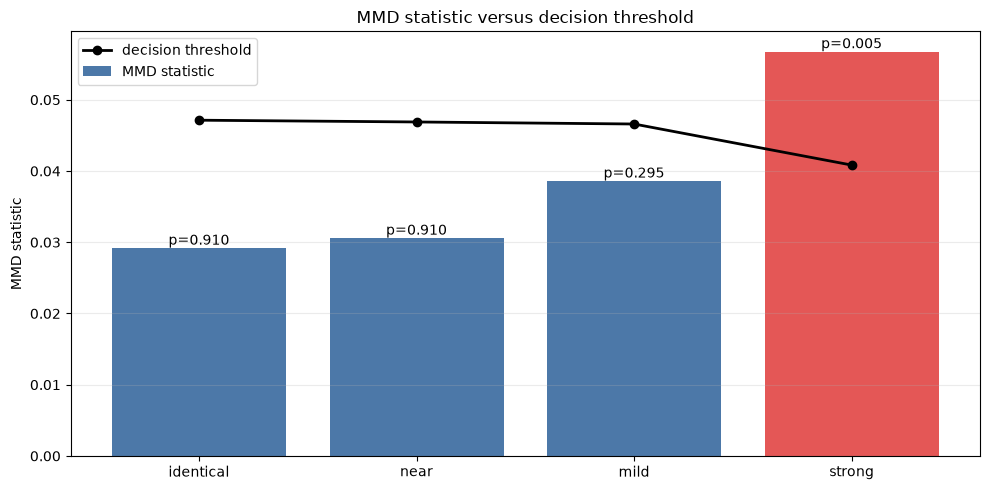

Local acceptance checks passed: identical=False and strong=True.


In [5]:
build_payloads(manifest, DATA_ROOT)
generated_root = DATA_ROOT / "generated"
reference_payload = json.loads(
    (generated_root / "reference_upload.json").read_text(encoding="utf-8")
)
reference_result = trustyai_client.upload(
    compact_request_inputs(reference_payload)
)
if reference_result.get("status") != "success":
    raise RuntimeError(f"Reference upload failed: {reference_result}")

mmd_rows = []
for case in manifest.cases:
    current_payload = json.loads(
        (generated_root / f"current_{case}.json").read_text(encoding="utf-8")
    )
    current_response = predict_request(
        current_payload,
        model_name="image-mmd-model",
    )
    current_upload = {
        "model_name": current_payload["model_name"],
        "request": {
            "id": current_payload["id"],
            "inputs": current_payload["inputs"],
        },
        "response": current_response,
    }
    current_result = trustyai_client.upload(
        compact_request_inputs(current_upload)
    )
    if current_result.get("status") != "success":
        raise RuntimeError(f"{case} upload failed: {current_result}")
    mmd_result = trustyai_client.compute_mmd(
        {
            "modelId": "image-mmd-model",
            "referenceTag": "IMAGE_BASELINE",
            "batchSize": manifest.sample_size,
            "method": "ctt",
            "alpha": 0.05,
            "seed": 7,
            "numPermutations": 199,
            "fitColumns": [f"embedding-{index}" for index in range(54)],
        }
    )
    if mmd_result.get("status") != "success":
        raise RuntimeError(f"{case} MMD computation failed: {mmd_result}")
    mmd_rows.append(
        {
            "case": case,
            "condition": (
                f"{manifest.samples[0].reference.condition} -> "
                f"{manifest.samples[0].current[case].condition}"
            ),
            "statistic": float(mmd_result["value"]),
            "p_value": float(mmd_result["p_value"]),
            "threshold": float(mmd_result["threshold"]),
            "drift_detected": bool(mmd_result["drift_detected"]),
        }
    )

mmd_table = pd.DataFrame(mmd_rows)
display(
    mmd_table.style.format(
        {
            "statistic": "{:.6f}",
            "p_value": "{:.3f}",
            "threshold": "{:.6f}",
        }
    )
)

positions = np.arange(len(mmd_table))
colors = ["#4c78a8" if not detected else "#e45756" for detected in mmd_table["drift_detected"]]
figure, axis = plt.subplots(figsize=(10, 5))
axis.bar(positions, mmd_table["statistic"], color=colors, label="MMD statistic")
axis.plot(
    positions,
    mmd_table["threshold"],
    color="black",
    marker="o",
    linewidth=2,
    label="decision threshold",
)
for position, row in mmd_table.iterrows():
    axis.text(
        position,
        row["statistic"],
        f"p={row['p_value']:.3f}",
        ha="center",
        va="bottom",
    )
axis.set_xticks(positions, mmd_table["case"])
axis.set_ylabel("MMD statistic")
axis.set_title("MMD statistic versus decision threshold")
axis.legend()
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()

assert bool(mmd_table.loc[mmd_table["case"] == "identical", "drift_detected"].iloc[0]) is False
assert bool(mmd_table.loc[mmd_table["case"] == "strong", "drift_detected"].iloc[0]) is True
print("Local acceptance checks passed: identical=False and strong=True.")

## Takeaways

- The images are real external-dataset members selected by the manifest; synthetic images are not used in the experiment.
- The 54-dimensional encoder makes the transport contract deterministic and inspectable.
- The identical case is a no-drift sanity check, while strong is a positive drift case.
- Near and mild are useful calibration observations for this small demonstration.
- The notebook can be rerun with an alternate compatible manifest by setting `IMAGE_MMD_MANIFEST` and `IMAGE_MMD_DATA_ROOT`.